In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

import matplotlib
# from matplotlib.image import NonUniformImage
# from scipy.stats import gmean
# imports 
# from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity
# from bbhx.waveformbuild import BBHWaveformFD
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13

# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
import math
import pickle


In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv("jillian.txt", sep="\t", dtype={"time (Gyr)": float, "mass ratio": float, "redshift": float, "total BH mass (Msun)": float})

In [4]:
time= df['time (Gyr)']
ratio= df['mass ratio']
z=np.array(df['redshift'])
M=df['total BH mass (Msun)']
m1=np.array(M/(1+ratio))
m2=np.array(ratio*m1)
plt.loglog(m1,m2,'o')

In [5]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value/1e3) ## in Gpc

In [6]:
bh=24
parameters = {
    'T': 2 / 52,  # duration in years
    'dt': 10.0,  # timestep in seconds
    'M': 1e6,  # primary mass
    'a': 0.0,  # spin, ignored in Schwarzschild waveform
    'mu': 1e4,  # secondary mass
    'p0': 16,  # initial semi-latus rectum
    'e0': 0,  # initial eccentricity
    'x0': 1.0,  # initial frequency param, ignored in Schwarzschild
    'qK': 0.0,  # polar spin angle
    'phiK': 0,  # azimuthal spin angle
    'qS': 0.3,  # polar sky angle
    'phiS': 0.3,  # azimuthal sky angle
    'dist': 1.0,  # luminosity distance in Gpc
    'Phi_phi0': 0.0,  # initial phase
    'Phi_theta0': 0.0,
    'Phi_r0': 0.0,
    'dt': 10,
}


In [7]:
from lisatools.sources.emri import EMRITDIWaveform
emri_lisa = EMRITDIWaveform(T=1/12., dt=10.,
    response_kwargs=dict(tdi_chan="AET", tdi="1st generation"),
    emri_waveform_kwargs=dict(inspiral_kwargs=dict(integrate_backwards=True)),
)


In [8]:
from lisatools.sensitivity import LISASens, get_sensitivity, get_stock_sensitivity_options

In [9]:
import lisatools.detector as lisa_models

In [10]:
get_stock_sensitivity_options()

['X1TDISens',
 'Y1TDISens',
 'Z1TDISens',
 'XY1TDISens',
 'YZ1TDISens',
 'ZX1TDISens',
 'A1TDISens',
 'E1TDISens',
 'T1TDISens',
 'X2TDISens',
 'Y2TDISens',
 'Z2TDISens',
 'LISASens',
 'CornishLISASens',
 'FlatPSDFunction']

In [11]:
lisa_models.sangria

LISAModel(Soms_d=6.241e-23, Sa_a=5.76e-30, orbits=<lisatools.detector.DefaultOrbits object at 0x7c306ed32650>, name='sangria')

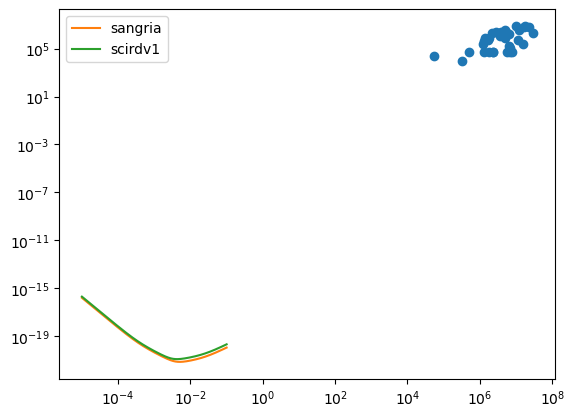

In [12]:
freq =np.logspace(-5, -1, 1000)
Sn_1 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.sangria, return_type='char_strain')
Sn_2 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.scirdv1, return_type='char_strain')

plt.loglog(freq, Sn_1, label="sangria")
plt.loglog(freq, Sn_2, label="scirdv1")
plt.legend()
plt.show()

In [13]:
Sn_1 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.sangria, return_type='char_strain')

Sn_2 = get_sensitivity(freq, sens_fn=LISASens, average=False, model=lisa_models.sangria, return_type='char_strain')
Sn_1/Sn_2

array([2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889, 2.5819889,
       2.5819889, 2.5819889, 2.5819889, 2.5819889, 

In [14]:
from lisatools.sensitivity import SensitivityMatrix, LISASens, A1TDISens

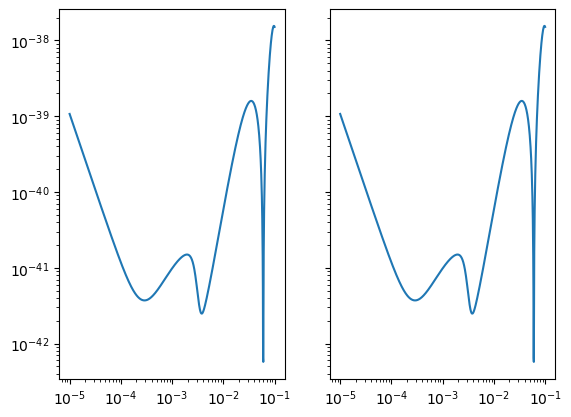

In [15]:
sens_kwargs = dict(
    stochastic_params=(1*YRSID_SI,)
)

sens_mat= SensitivityMatrix(freq,[A1TDISens,A1TDISens], **sens_kwargs)
sens_mat.loglog()
plt.show()

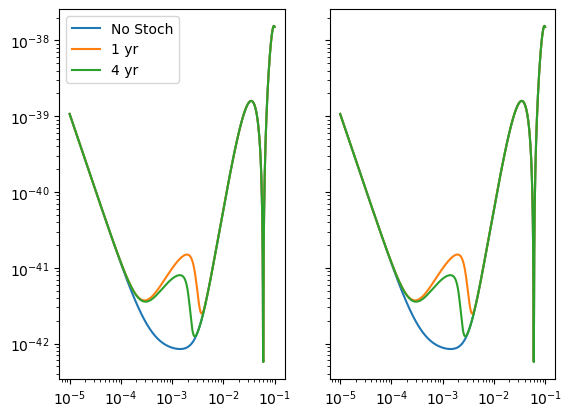

In [16]:
# clear (for internal clearing of answers)
 
sens_mat_no_confusion = deepcopy(sens_mat)
sens_mat_no_confusion.update_stochastic(stochastic_params=None)

sens_mat_1_yr = deepcopy(sens_mat)
sens_mat_1_yr.update_stochastic(stochastic_params=(1 * YRSID_SI,))

sens_mat_4_yr = deepcopy(sens_mat)
sens_mat_4_yr.update_stochastic(stochastic_params=(4 * YRSID_SI,))

fig, ax = sens_mat_no_confusion.loglog(label="No Stoch")

sens_mat_1_yr.loglog(fig=fig, ax=ax, label="1 yr")
sens_mat_4_yr.loglog(fig=fig, ax=ax, label="4 yr")
ax[0].legend()
plt.show()

In [18]:
dt=10
Tobs=1*YRSID_SI
Nobs=int(Tobs/dt)
t=np.arange(Nobs)*dt

In [19]:
print(t)

[       0       10       20 ... 31558110 31558120 31558130]


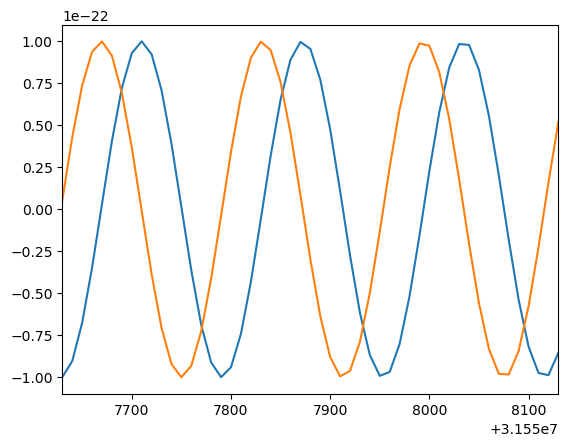

In [20]:
A = 1e-22
f0 = 3e-3
fdot = 1e-10
phi0 = 4.2

h1 = A * np.sin(2 * np.pi * (f0 * t + 1/2 * fdot * t ** 2) + phi0)
h2 = A * np.cos(2 * np.pi * (f0 * t + 1/2 * fdot * t ** 2) + phi0)
plt.plot(t, h1, label="h1")
plt.plot(t, h2, label="h2")
plt.xlim(t[-1] - 500.0, t[-1])
plt.show()


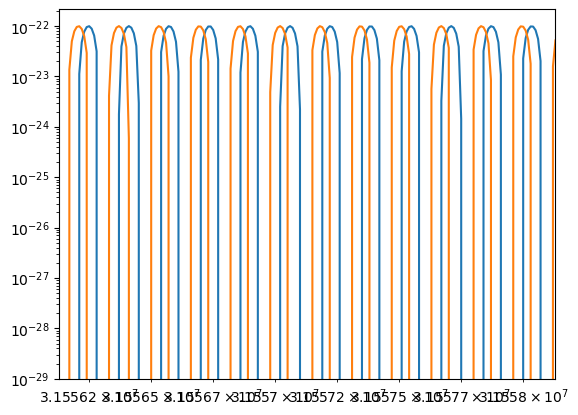

In [21]:
plt.loglog(t, h1, label="h1")
plt.loglog(t, h2, label="h2")
plt.xlim(t[-1] - 2000.0, t[-1])
plt.show()

In [22]:
from lisatools.datacontainer import DataResidualArray

In [23]:
data_res_arr= DataResidualArray([h1, h2], dt=dt)

In [24]:
%matplotlib widget

In [ ]:
# %matplotlib qt

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


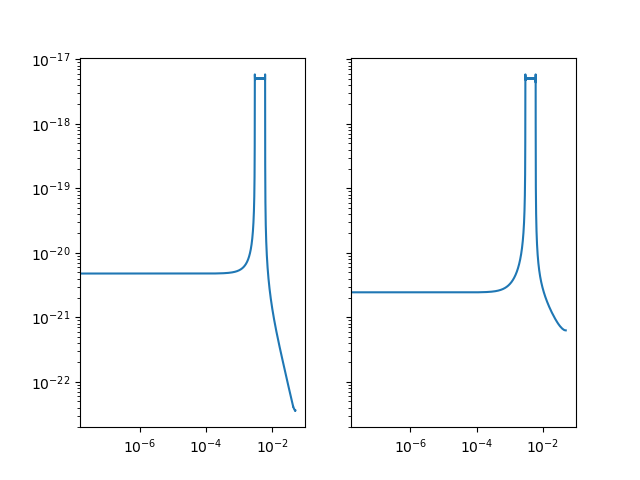

In [25]:
fig, ax = data_res_arr.loglog()
# ax[0].set_xlim(3e-3,4e-3)
# ax[1].set_xlim(3e-3,4e-3)
# ax[0].set_ylim(1e-18,1e-17)
# ax[1].set_ylim(1e-18,1e-17)
plt.show()
# %matplotlib qt

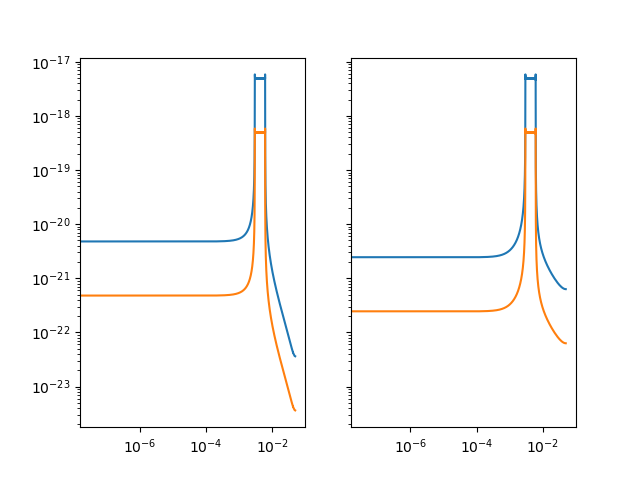

In [27]:
# clear (for internal clearing of answers)
 
fig, ax = data_res_arr.loglog()
h1_f = np.abs(np.fft.rfft(h1))
h2_f = np.abs(np.fft.rfft(h2))
ax[0].loglog(data_res_arr.f_arr, h1_f)
ax[1].loglog(data_res_arr.f_arr, h2_f)

In [28]:
np.abs(data_res_arr[0]) / h1_f

array([10., 10., 10., ..., 10., 10., 10.], shape=(1577908,))

In [29]:
from lisatools.analysiscontainer import AnalysisContainer

(1e-24, 1e-18)

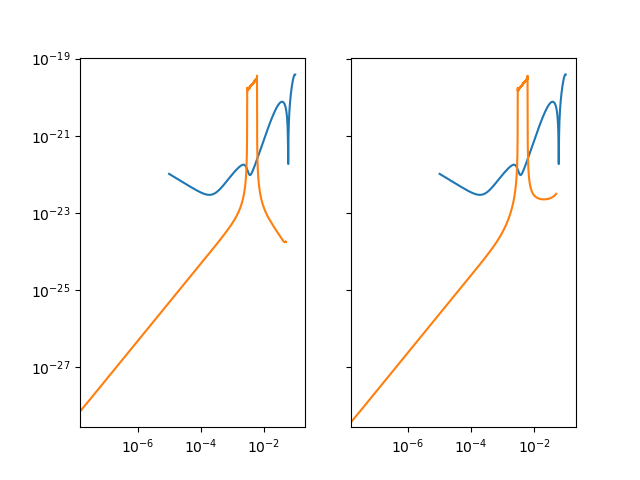

In [30]:
analysis = AnalysisContainer(data_res_arr, sens_mat)
fig, ax2 = analysis.loglog()
ax[0].set_ylim(1e-24,1e-18)

In [82]:
A_new = A # 1.01e-22
f0_new = f0 # 3.0000003e-3
fdot_new = fdot * (1.000001)
phi0_new = phi0  # 3.1 
 
h1_new = A_new * np.sin(2 * np.pi * (f0_new * t + 1/2 * fdot_new * t ** 2) + phi0_new)
h2_new = A_new * np.cos(2 * np.pi * (f0_new * t + 1/2 * fdot_new * t ** 2) + phi0_new)

In [83]:
template = DataResidualArray([h1_new, h2_new], dt=dt)


In [84]:
sens_mat.update_frequency_arr(templete.f_arr)

/home/karmakar/anaconda3/envs/few_2_env/lib/python3.13/site-packages/lisatools/detector.py:633: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/karmakar/anaconda3/envs/few_2_env/lib/python3.13/site-packages/lisatools/detector.py:635: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/karmakar/anaconda3/envs/few_2_env/lib/python3.13/site-packages/lisatools/detector.py:637: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/karmakar/anaconda3/envs/few_2_env/lib/python3.13/site-packages/lisatools/detector.py:642: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/karmakar/anaconda3/envs/few_2_env/lib/python3.13/site-packages/lisatools/detector.py:644: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

In [ ]:
# why we aare dividing my sensitivity
# difference in template and nomal inner product
# is the inner product with itself is snr?

In [85]:
h_old_h_new = 4*template.df*np.real(np.sum(template[:,1:].conj()* data_res_arr[:,1:]/ sens_mat[:,1:]))

In [79]:
h_old_h_new, h_old_h_new_same

(np.float64(157265.40056575966), np.float64(158170.1929376628))

In [73]:
analysis.inner_product()

158170.19293766312

In [74]:
analysis.template_inner_product(template)

157265.40056575954

In [81]:
hnew_hnew = 4 * template.df * np.real(np.sum(template[:, 1:].conj() * template[:, 1:] / sens_mat[:, 1:]))
print(hnew_hnew)
print(f"Opt SNR: {np.sqrt(hnew_hnew)}, Det SNR: {h_old_h_new / np.sqrt(hnew_hnew)}")

158170.1929376628
Opt SNR: 397.70616406797467, Det SNR: 395.431136789925


In [86]:
opt_snr, det_snr = analysis.template_snr(template)
print(f"Opt SNR: {opt_snr}, Det SNR: {det_snr}")

Opt SNR: 397.7059077307561, Det SNR: 395.4313916609633


In [87]:
r1 = h1_new - h1
r2 = h2_new - h2

residual = DataResidualArray([r1, r2], dt=dt)

In [88]:
analysis_res = AnalysisContainer(residual, sens_mat)

In [89]:
print(analysis_res.inner_product())

1809.3808500887071


In [90]:
likelihood = -1/2 * analysis_res.inner_product()
print(f"Likelihoood: {likelihood}")

Likelihoood: -904.6904250443536


In [91]:
analysis.template_likelihood(template)

np.float64(-904.6904250443622)